Columns in dataset: ['YEAR', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
   YEAR     JAN     FEB     MAR     APR     MAY     JUN       JUL       AUG  \
0  1992  146925  147223  146805  148032  149010  149800  150761.0  151067.0   
1  1993  157555  156266  154752  158979  160605  160127  162816.0  162506.0   
2  1994  167518  169649  172766  173106  172329  174241  174781.0  177295.0   
3  1995  182413  179488  181013  181686  183536  186081  185431.0  186806.0   
4  1996  189135  192266  194029  194744  196205  196136  196187.0  196218.0   

        SEP       OCT       NOV       DEC  
0  152588.0  153521.0  153583.0  155614.0  
1  163258.0  164685.0  166594.0  168161.0  
2  178787.0  180561.0  180703.0  181524.0  
3  187366.0  186565.0  189055.0  190774.0  
4  198859.0  200509.0  200174.0  201284.0  


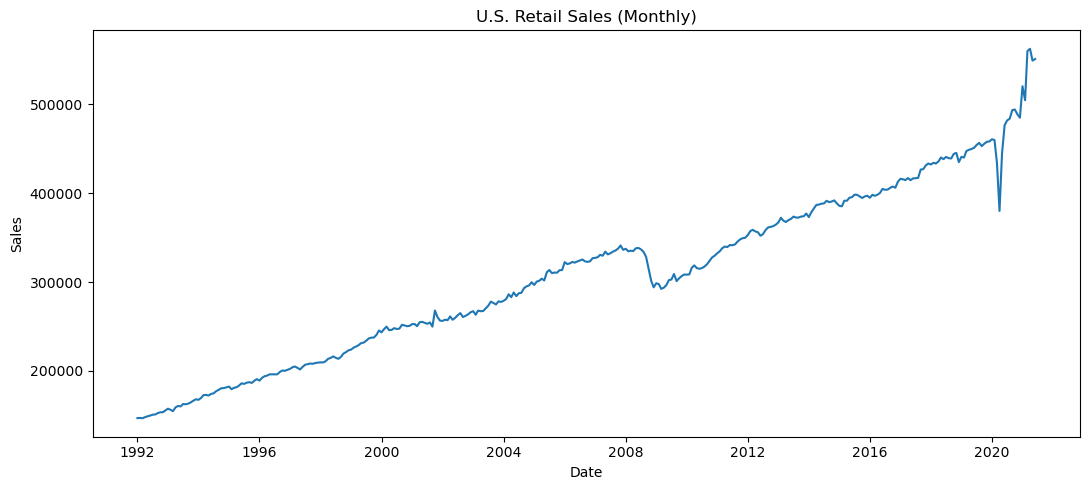

Data span: 1992-01-01 to 2021-12-01
Rows: 360


,Sales
Date,
1992-01-01,146925.0
1992-02-01,147223.0
1992-03-01,146805.0
1992-04-01,148032.0
1992-05-01,149010.0


In [16]:
# Step 1: Load data and reshape monthly U.S. retail sales 
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(r"C:\Users\gjose\DSC630-T302\us_retail_sales.csv")
print("Columns in dataset:", df.columns.tolist())
print(df.head())

# Melt the wide format so each month is a row instead of a column
df_long = df.melt(id_vars=['YEAR'], var_name='Month', value_name='Sales')

# Convert month abbreviations to numbers
month_map = {
    'JAN': 1, 'FEB': 2, 'MAR': 3, 'APR': 4, 'MAY': 5, 'JUN': 6,
    'JUL': 7, 'AUG': 8, 'SEP': 9, 'OCT': 10, 'NOV': 11, 'DEC': 12
}
df_long['Month'] = df_long['Month'].map(month_map)

# Create a datetime column
df_long['Date'] = pd.to_datetime(dict(year=df_long['YEAR'], month=df_long['Month'], day=1))

# Sort and set the date as index
df_long = df_long.sort_values('Date').set_index('Date')

# Keep only the date and sales columns
df_final = df_long[['Sales']].copy()

# Plot
plt.figure(figsize=(11,5))
plt.plot(df_final.index, df_final['Sales'])
plt.title("U.S. Retail Sales (Monthly)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

print("Data span:", df_final.index.min().date(), "to", df_final.index.max().date())
print("Rows:", len(df_final))
df_final.head()



Observations:

• The series shows a long-term upward trend (retail sales generally increase over time).

• There appears to be seasonality (recurring ups/downs across years, seemingly around holidays).

• The COVID-19 period (2020) show sharp movements (drop then rebound).

In [21]:
# Step 2: Split data — last 12 months as test (July 2020–June 2021)

split_date = "2020-06-01"   # last month in training set
series = df_final["Sales"].asfreq("MS")  # ensure monthly start freq

train = series.loc[:split_date].copy()
test  = series.loc["2020-07-01":"2021-06-01"].copy()

print("Train range:", train.index.min().date(), "to", train.index.max().date(), "| n =", len(train))
print("Test  range:",  test.index.min().date(),  "to", test.index.max().date(),  "| n =", len(test))
assert len(test) == 12, "Test set should have 12 months (July 2020–June 2021)."



Train range: 1992-01-01 to 2020-06-01 | n = 342
Test  range: 2020-07-01 to 2021-06-01 | n = 12


In [23]:
# Step 3: Fit a predictive model on the training set
import warnings
warnings.filterwarnings("ignore")

fitted_model = None
used_auto_arima = False

try:
    # Try auto_arima 
    from pmdarima import auto_arima
    used_auto_arima = True
    arima = auto_arima(
        train,
        seasonal=True, m=12,          # monthly seasonality
        stepwise=True,
        suppress_warnings=True,
        error_action='ignore',
        trace=False
    )
    fitted_model = arima
    print("Model: auto_arima selected order:", arima.order, "seasonal_order:", arima.seasonal_order)
except Exception as e:
    print("auto_arima not available or failed. Falling back to SARIMAX. Reason:", e)
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    sarimax = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12),
                      enforce_stationarity=False, enforce_invertibility=False)
    fitted_model = sarimax.fit(disp=False)
    print("Model: SARIMAX(1,1,1)x(1,1,1,12) fitted.")




auto_arima not available or failed. Falling back to SARIMAX. Reason: No module named 'pmdarima'
Model: SARIMAX(1,1,1)x(1,1,1,12) fitted.


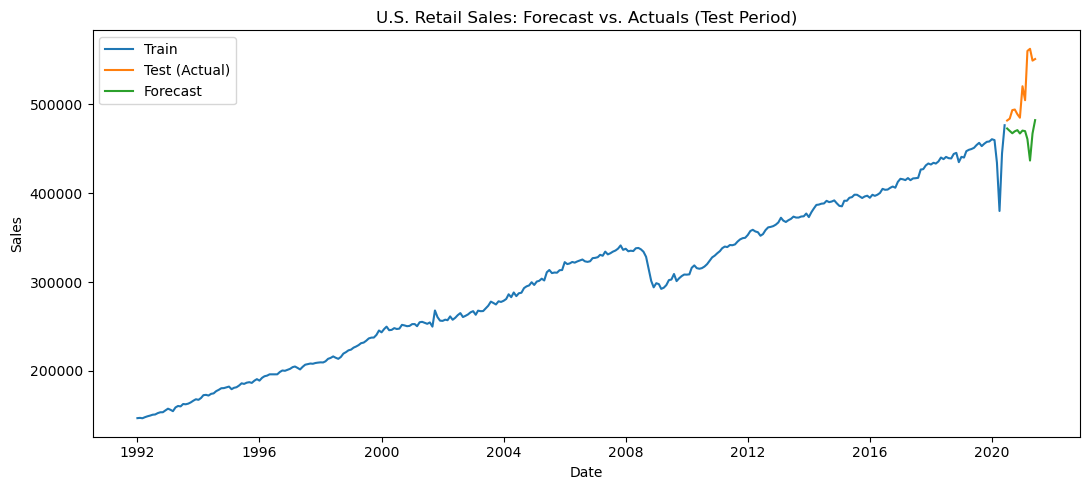

Test RMSE: 59,819.07


In [14]:
# Step 4: Forecast the last 12 months and evaluate
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import pandas as pd

h = len(test)  # 12 months

if used_auto_arima:
    preds = fitted_model.predict(n_periods=h)
    preds = pd.Series(preds, index=test.index, name="forecast")
else:
    preds = fitted_model.get_forecast(steps=h).predicted_mean
    preds.name = "forecast"

# Plot actual vs forecast
plt.figure(figsize=(11,5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index,  test,  label="Test (Actual)")
plt.plot(preds.index, preds, label="Forecast")
plt.title("U.S. Retail Sales: Forecast vs. Actuals (Test Period)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()

# RMSE
rmse = mean_squared_error(test, preds, squared=False)
print(f"Test RMSE: {rmse:,.2f}")

